# Fraud Detection MLOps Pipeline
## Phase 2 - Model Development and Training
---
**Input**  : processed_fraudTrain.csv / processed_fraudTest.csv  
**Models** : XGBoost + Deep Learning (TensorFlow/Keras)  
**AWS**    : SageMaker Training Jobs, HPO, Experiments, Clarify, Model Registry  
---

## Step 0 - Install Dependencies

In [1]:
!pip install xgboost imbalanced-learn shap -q
print('Done')

Done


## Step 1 - Setup and Configuration

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import warnings
import json
import time
warnings.filterwarnings('ignore')

import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

tf.get_logger().setLevel('ERROR')

# Color palette
FRAUD  = '#E63946'
LEGIT  = '#2A9D8F'
ACC1   = '#F4A261'
ACC2   = '#457B9D'
DARK   = '#0D1117'
CARD   = '#161B22'
GRID   = '#21262D'
TEXT   = '#C9D1D9'
MUTED  = '#8B949E'
XGBC   = '#F4A261'
DLC    = '#A8DADC'

HEAT_CMAP = LinearSegmentedColormap.from_list(
    'heat', ['#0D1117','#264653','#2A9D8F','#E9C46A','#E63946'])

plt.rcParams.update({
    'figure.facecolor' : DARK,
    'axes.facecolor'   : CARD,
    'axes.edgecolor'   : GRID,
    'axes.labelcolor'  : TEXT,
    'axes.titlecolor'  : '#FFFFFF',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'axes.grid'        : True,
    'grid.color'       : GRID,
    'grid.linewidth'   : 0.6,
    'text.color'       : TEXT,
    'xtick.color'      : MUTED,
    'ytick.color'      : MUTED,
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
    'legend.facecolor' : CARD,
    'legend.edgecolor' : GRID,
    'legend.fontsize'  : 9,
    'figure.titlesize' : 15,
    'figure.titleweight': 'bold',
    'figure.dpi'       : 130,
    'savefig.dpi'      : 180,
    'savefig.facecolor': DARK,
    'savefig.bbox'     : 'tight',
    'lines.linewidth'  : 1.8,
})

print('TensorFlow :', tf.__version__)
print('XGBoost    :', xgb.__version__)
print('Setup complete!')

TensorFlow : 2.19.1
XGBoost    : 2.1.4
Setup complete!


## Step 2 - Load Processed Data

In [5]:
train_df = pd.read_csv('processed_fraudTrain.csv')
test_df  = pd.read_csv('processed_fraudTest.csv')

TARGET   = 'is_fraud'
FEATURES = [c for c in train_df.columns if c != TARGET]

# Clean NaN just in case
train_df = train_df.fillna(0)
test_df  = test_df.fillna(0)

X_train = train_df[FEATURES].values.astype(float)
y_train = train_df[TARGET].values.astype(int)
X_test  = test_df[FEATURES].values.astype(float)
y_test  = test_df[TARGET].values.astype(int)

# Replace any inf values
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_test  = np.nan_to_num(X_test,  nan=0.0, posinf=0.0, neginf=0.0)

print('Data loaded successfully!')
print('Train rows :', X_train.shape[0])
print('Test  rows :', X_test.shape[0])
print('Features   :', X_train.shape[1])
print('Fraud% train:', round(y_train.mean()*100, 3), '%')
print('Fraud% test :', round(y_test.mean()*100, 3), '%')
train_df.head(3)

Data loaded successfully!
Train rows : 407073
Test  rows : 403165
Features   : 20
Fraud% train: 0.656 %
Fraud% test : 0.457 %


,amt,log_amt,amt_zscore,distance_km,log_city_pop,is_small_city,hour,day_num,month_num,is_weekend,...,is_peak_hours,age,is_senior,is_young,card_txn_freq,high_freq_card,category_fraud_rate,gender_enc,category_enc,is_fraud
0,-0.414211,-1.356870,-0.414211,0.084229,-0.084760,1,0,1,1,0,...,0,-0.822846,0,0,0.380410,0,0.015223,0,8,0.0
1,0.231324,0.890684,0.231324,-1.579187,-1.367211,1,0,1,1,0,...,0,-0.247345,0,0,1.764813,1,0.016109,0,4,0.0
2,0.943900,1.444834,0.943900,1.102125,-0.014424,1,0,1,1,0,...,0,0.673457,0,0,-1.743634,0,0.002581,1,0,0.0


## Step 3 - Handle Class Imbalance with SMOTE

Applying SMOTE...


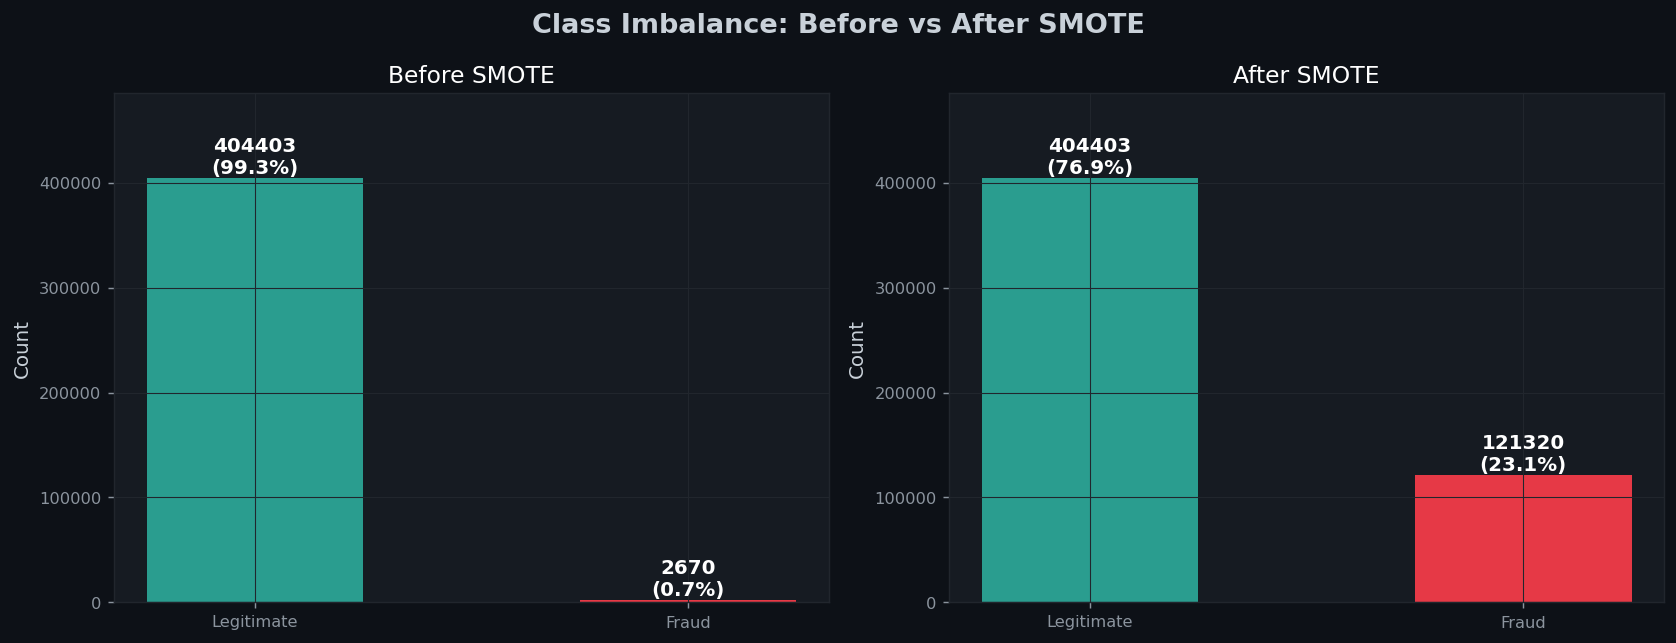

Before: 404403 legit | 2670 fraud
After : 404403 legit | 121320 fraud
Class weights - Legit: 0.503 | Fraud: 76.231


In [6]:
print('Applying SMOTE...')
smote = SMOTE(random_state=42, k_neighbors=5, sampling_strategy=0.3)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

cw       = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
class_wt = {0: float(cw[0]), 1: float(cw[1])}

# Chart 1 - Before vs After SMOTE
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Class Imbalance: Before vs After SMOTE', fontweight='bold')

for ax, counts, title in zip(
    axes,
    [np.bincount(y_train), np.bincount(y_train_res)],
    ['Before SMOTE', 'After SMOTE']
):
    bars = ax.bar(['Legitimate', 'Fraud'], counts,
                  color=[LEGIT, FRAUD], edgecolor='none', width=0.5)
    for bar, cnt in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(counts)*0.01,
            str(cnt) + '\n(' + str(round(cnt/sum(counts)*100, 1)) + '%)',
            ha='center', fontsize=11, color='white', fontweight='bold'
        )
    ax.set_title(title)
    ax.set_ylabel('Count')
    ax.set_ylim(0, max(counts)*1.2)

plt.tight_layout()
plt.savefig('p2_chart1_smote.png')
plt.show()

print('Before:', np.bincount(y_train)[0], 'legit |', np.bincount(y_train)[1], 'fraud')
print('After :', np.bincount(y_train_res)[0], 'legit |', np.bincount(y_train_res)[1], 'fraud')
print('Class weights - Legit:', round(class_wt[0],3), '| Fraud:', round(class_wt[1],3))

## Step 4 - Model 1: XGBoost Classifier

In [7]:
# Note: early_stopping_rounds goes in constructor in newer XGBoost versions
XGB_PARAMS = {
    'n_estimators'        : 500,
    'max_depth'           : 6,
    'learning_rate'       : 0.05,
    'subsample'           : 0.8,
    'colsample_bytree'    : 0.8,
    'min_child_weight'    : 5,
    'gamma'               : 0.1,
    'reg_alpha'           : 0.1,
    'reg_lambda'          : 1.0,
    'scale_pos_weight'    : int(np.bincount(y_train)[0]/np.bincount(y_train)[1]),
    'eval_metric'         : 'aucpr',
    'early_stopping_rounds': 30,
    'random_state'        : 42,
    'n_jobs'              : -1,
    'tree_method'         : 'hist',
}

xgb_model = xgb.XGBClassifier(**XGB_PARAMS)

print('Training XGBoost...')
start = time.time()
xgb_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test, y_test)],
    verbose=50
)
xgb_time = time.time() - start
print('Done in', round(xgb_time, 1), 's')

Training XGBoost...
[0]	validation_0-aucpr:0.37091
[50]	validation_0-aucpr:0.59908
[100]	validation_0-aucpr:0.77279
[150]	validation_0-aucpr:0.81255
[200]	validation_0-aucpr:0.83465
[250]	validation_0-aucpr:0.84618
[300]	validation_0-aucpr:0.85500
[350]	validation_0-aucpr:0.85850
[400]	validation_0-aucpr:0.85860
[410]	validation_0-aucpr:0.85929
Done in 80.5 s


In [8]:
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred  = (xgb_proba >= 0.5).astype(int)

xgb_metrics = {
    'AUC-ROC'  : roc_auc_score(y_test, xgb_proba),
    'AUC-PR'   : average_precision_score(y_test, xgb_proba),
    'F1-Score' : f1_score(y_test, xgb_pred),
    'Precision': precision_score(y_test, xgb_pred),
    'Recall'   : recall_score(y_test, xgb_pred),
}

print('XGBoost Performance:')
print('-' * 40)
for k, v in xgb_metrics.items():
    bar = '#' * int(v * 30)
    print(' ', k.ljust(15), ':', round(v, 4), ' ', bar)

XGBoost Performance:
----------------------------------------
  AUC-ROC         : 0.9955   #############################
  AUC-PR          : 0.8599   #########################
  F1-Score        : 0.6631   ###################
  Precision       : 0.5356   ################
  Recall          : 0.8703   ##########################


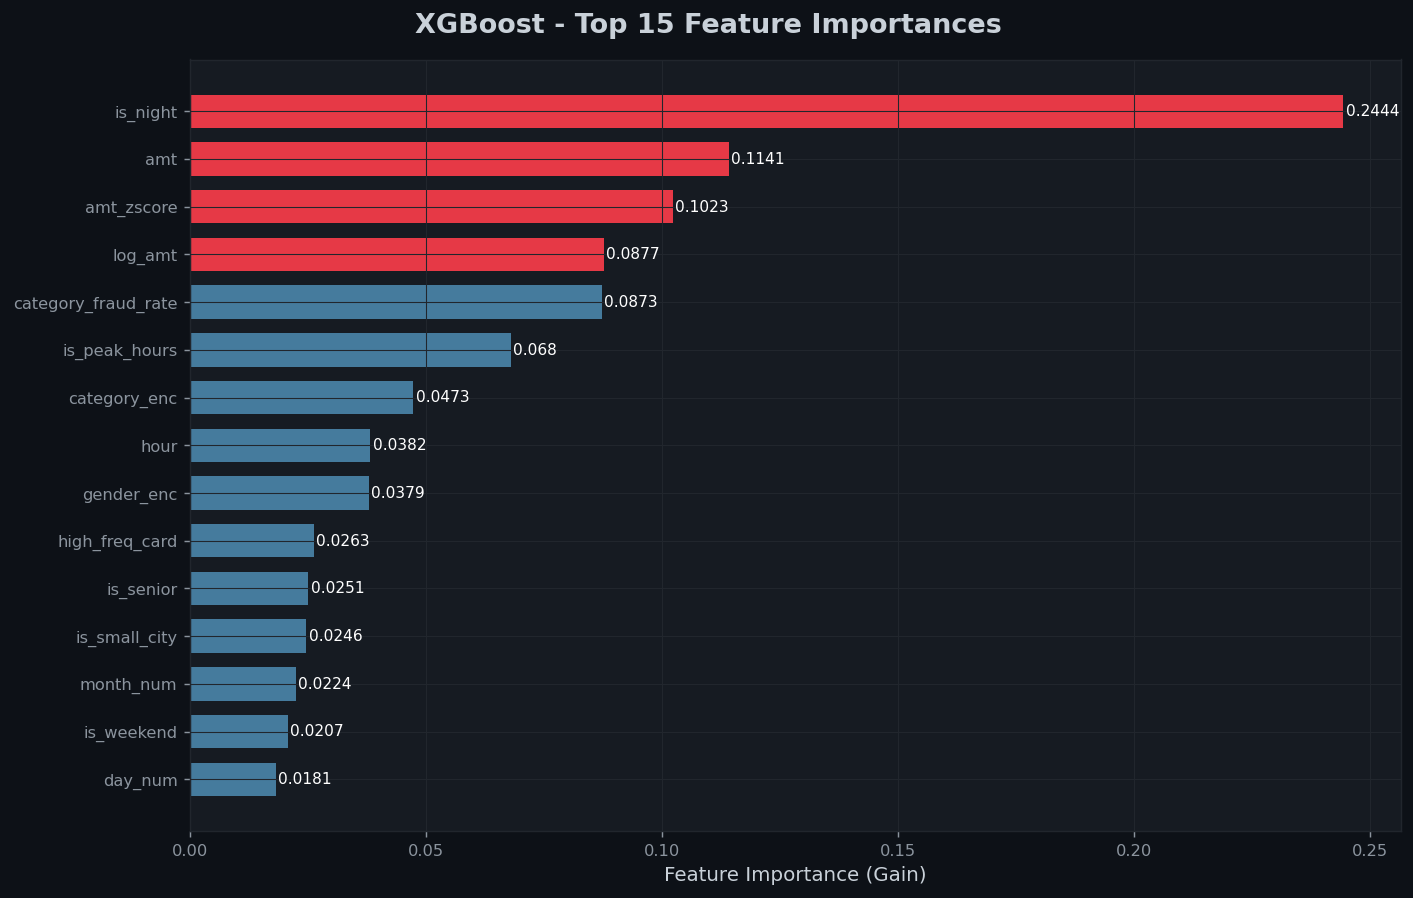

In [9]:
# Chart 2 - Feature Importance
feat_imp = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(11, 7))
fig.suptitle('XGBoost - Top 15 Feature Importances', fontweight='bold')

clrs = [FRAUD if v > feat_imp['importance'].quantile(0.75) else ACC2
        for v in feat_imp['importance']]
bars = ax.barh(feat_imp['feature'], feat_imp['importance'],
               color=clrs, edgecolor='none', height=0.7)
for bar, val in zip(bars, feat_imp['importance']):
    ax.text(bar.get_width() + 0.0005,
            bar.get_y() + bar.get_height()/2,
            str(round(val, 4)),
            va='center', fontsize=8.5, color='white')
ax.set_xlabel('Feature Importance (Gain)')

plt.tight_layout()
plt.savefig('p2_chart2_importance.png')
plt.show()

## Step 5 - Model 2: Deep Learning (TensorFlow/Keras)

In [10]:
def build_model(input_dim):
    inputs = keras.Input(shape=(input_dim,), name='features')

    # Block 1
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(0.001))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)

    # Block 2
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)

    # Block 3 with residual connection
    skip = layers.Dense(64)(x)
    x    = layers.Dense(64, kernel_regularizer=regularizers.l2(0.001))(x)
    x    = layers.BatchNormalization()(x)
    x    = layers.Activation('relu')(x)
    x    = layers.Add()([x, skip])
    x    = layers.Dropout(0.2)(x)

    # Block 4
    x = layers.Dense(32, activation='relu')(x)

    # Output
    output = layers.Dense(1, activation='sigmoid', name='fraud_prob')(x)

    model = keras.Model(inputs, output, name='FraudNet')
    return model

nn_model = build_model(X_train_res.shape[1])
nn_model.summary()

Model: "FraudNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ features            │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │      5,376 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64)        │          0 │ activation_2[0][… │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fraud_prob (Dense)  │ (None, 1)         │         33 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 58,689 (229.25 KB)

 Trainable params: 57,793 (225.75 KB)

 Non-trainable params: 896 (3.50 KB)

In [11]:
nn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        keras.metrics.AUC(name='auc_roc'),
        keras.metrics.AUC(name='auc_pr', curve='PR'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)

cb_list = [
    callbacks.EarlyStopping(
        monitor='val_auc_pr', patience=8,
        restore_best_weights=True, mode='max', verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_auc_pr', factor=0.5,
        patience=4, min_lr=1e-6, verbose=1
    ),
    callbacks.ModelCheckpoint(
        'best_fraud_nn.keras', monitor='val_auc_pr',
        save_best_only=True, mode='max', verbose=0
    ),
]

print('Training Deep Learning model...')
start = time.time()
history = nn_model.fit(
    X_train_res, y_train_res,
    validation_data=(X_test, y_test),
    epochs=60,
    batch_size=2048,
    class_weight=class_wt,
    callbacks=cb_list,
    verbose=1
)
print('Done in', round(time.time()-start, 1), 's')

Training Deep Learning model...
Epoch 1/60


2026-06-24 10:16:15.123745: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 42057840 exceeds 10% of free system memory.


256/257 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - auc_pr: 0.6782 - auc_roc: 0.8877 - loss: 1.6779 - precision: 0.2469 - recall: 0.9965

2026-06-24 10:16:30.019514: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 32253200 exceeds 10% of free system memory.


257/257 ━━━━━━━━━━━━━━━━━━━━ 17s 51ms/step - auc_pr: 0.7656 - auc_roc: 0.9314 - loss: 1.3759 - precision: 0.2697 - recall: 0.9978 - val_auc_pr: 0.2534 - val_auc_roc: 0.9701 - val_loss: 0.7537 - val_precision: 0.0236 - val_recall: 0.9598 - learning_rate: 0.0010
Epoch 2/60
257/257 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - auc_pr: 0.8672 - auc_roc: 0.9707 - loss: 0.8594 - precision: 0.4263 - recall: 0.9974 - val_auc_pr: 0.2376 - val_auc_roc: 0.9780 - val_loss: 0.4787 - val_precision: 0.0417 - val_recall: 0.9441 - learning_rate: 0.0010
Epoch 3/60
257/257 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - auc_pr: 0.8878 - auc_roc: 0.9774 - loss: 0.6642 - precision: 0.5121 - recall: 0.9982 - val_auc_pr: 0.3425 - val_auc_roc: 0.9815 - val_loss: 0.4544 - val_precision: 0.0368 - val_recall: 0.9598 - learning_rate: 0.0010
Epoch 4/60
257/257 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - auc_pr: 0.8997 - auc_roc: 0.9806 - loss: 0.5651 - precision: 0.5510 - recall: 0.9987 - val_auc_pr: 0.3706 - val_auc_roc: 0.9844 - val_loss:

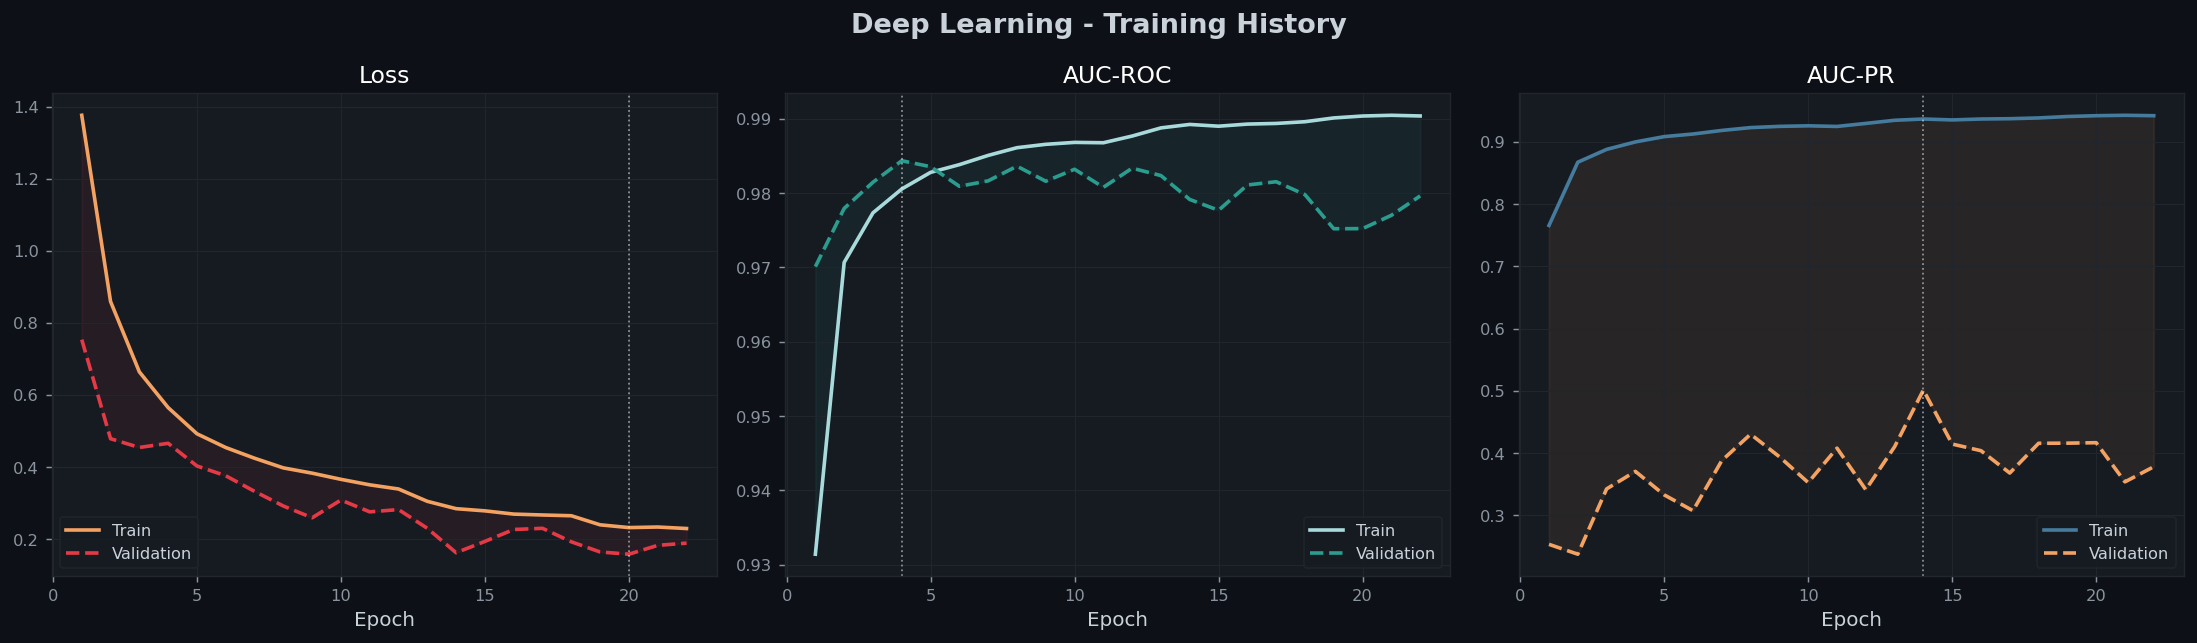

2026-06-24 10:21:38.256399: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 32253200 exceeds 10% of free system memory.


Deep Learning Performance:
  AUC-ROC         : 0.986
  AUC-PR          : 0.649
  F1-Score        : 0.2319
  Precision       : 0.1326
  Recall          : 0.923


In [12]:
# Chart 3 - Training History
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Deep Learning - Training History', fontweight='bold')

plots = [
    ('loss',    'val_loss',    'Loss',    ACC1,  FRAUD),
    ('auc_roc', 'val_auc_roc', 'AUC-ROC', DLC,   LEGIT),
    ('auc_pr',  'val_auc_pr',  'AUC-PR',  ACC2,  ACC1),
]

for ax, (tm, vm, title, c1, c2) in zip(axes, plots):
    ep = range(1, len(history.history[tm])+1)
    ax.plot(ep, history.history[tm], color=c1, linewidth=2, label='Train')
    ax.plot(ep, history.history[vm], color=c2, linewidth=2,
            label='Validation', linestyle='--')
    ax.fill_between(ep, history.history[tm],
                    history.history[vm], alpha=0.08, color=c2)
    if 'loss' in vm:
        best_ep = int(np.argmin(history.history[vm]))
    else:
        best_ep = int(np.argmax(history.history[vm]))
    best_val = history.history[vm][best_ep]
    ax.axvline(x=best_ep+1, color='white', linestyle=':', linewidth=1, alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()

plt.tight_layout()
plt.savefig('p2_chart3_history.png')
plt.show()

dl_proba = nn_model.predict(X_test, verbose=0).ravel()
dl_pred  = (dl_proba >= 0.5).astype(int)

dl_metrics = {
    'AUC-ROC'  : roc_auc_score(y_test, dl_proba),
    'AUC-PR'   : average_precision_score(y_test, dl_proba),
    'F1-Score' : f1_score(y_test, dl_pred),
    'Precision': precision_score(y_test, dl_pred),
    'Recall'   : recall_score(y_test, dl_pred),
}
print('Deep Learning Performance:')
for k, v in dl_metrics.items():
    print(' ', k.ljust(15), ':', round(v, 4))

## Step 6 - Model Comparison

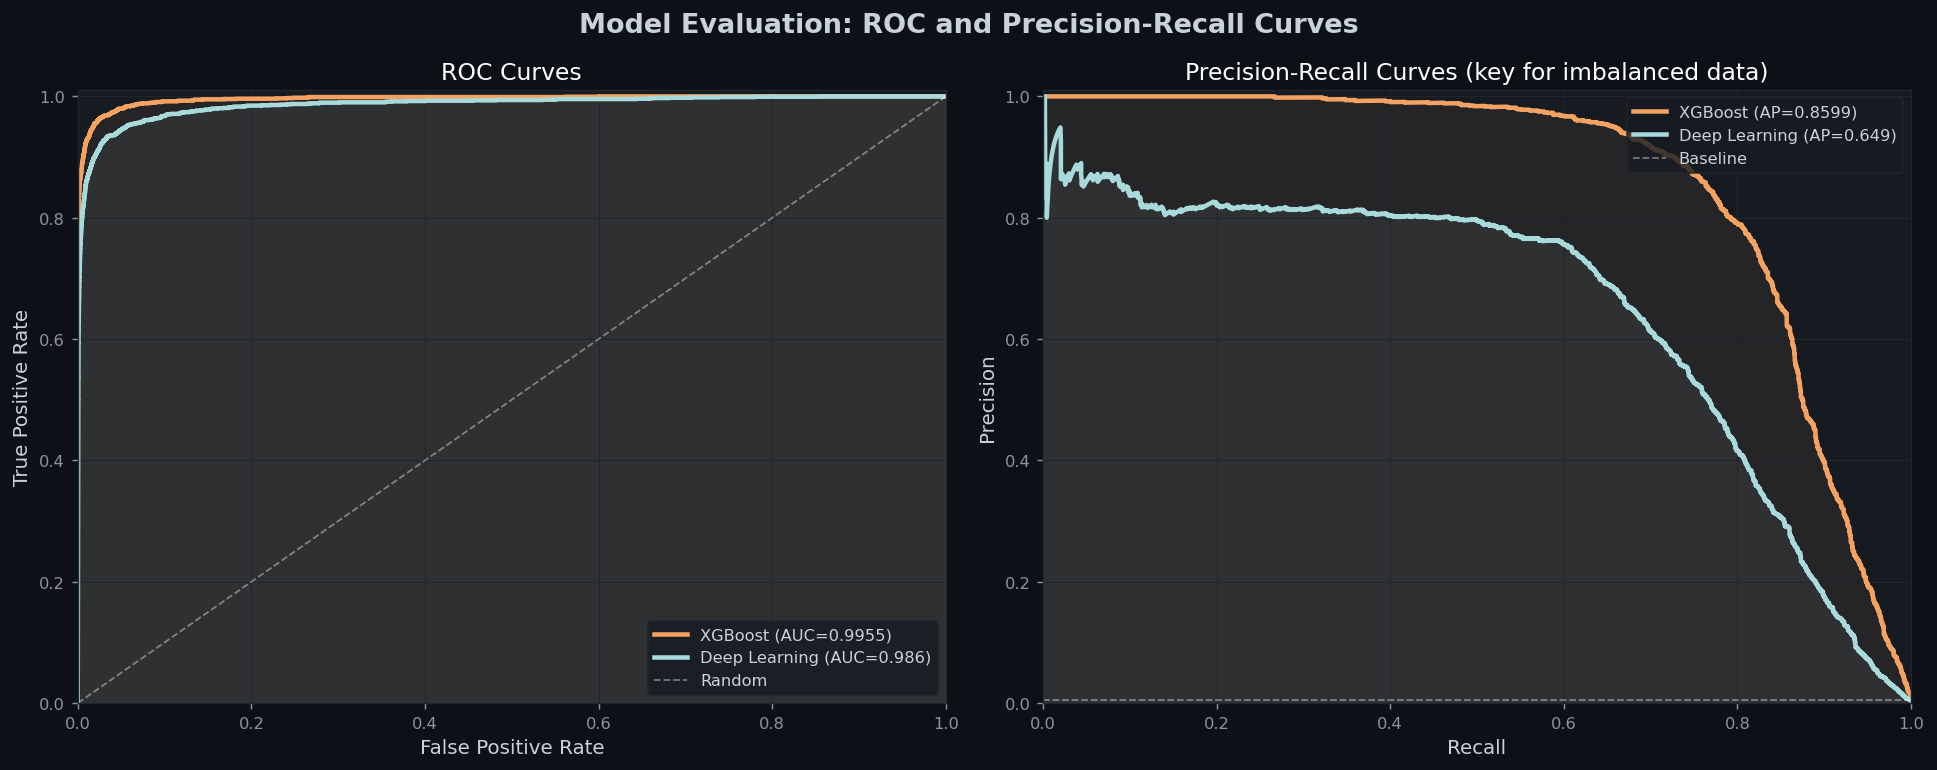

In [13]:
# Chart 4 - ROC and PR Curves
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Model Evaluation: ROC and Precision-Recall Curves', fontweight='bold')

model_info = [
    ('XGBoost',       xgb_proba, XGBC),
    ('Deep Learning', dl_proba,  DLC),
]

# ROC curves
for name, proba, color in model_info:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val      = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, linewidth=2.5,
                 label=name + ' (AUC=' + str(round(auc_val, 4)) + ')')
    axes[0].fill_between(fpr, tpr, alpha=0.07, color=color)
axes[0].plot([0,1],[0,1],'w--',linewidth=1,alpha=0.4,label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend(loc='lower right')
axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1.01])

# PR curves
for name, proba, color in model_info:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap_val        = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, color=color, linewidth=2.5,
                 label=name + ' (AP=' + str(round(ap_val, 4)) + ')')
    axes[1].fill_between(rec, prec, alpha=0.07, color=color)
axes[1].axhline(y=y_test.mean(), color='white', linestyle='--',
                linewidth=1, alpha=0.4, label='Baseline')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves (key for imbalanced data)')
axes[1].legend(loc='upper right')
axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.01])

plt.tight_layout()
plt.savefig('p2_chart4_roc_pr.png')
plt.show()

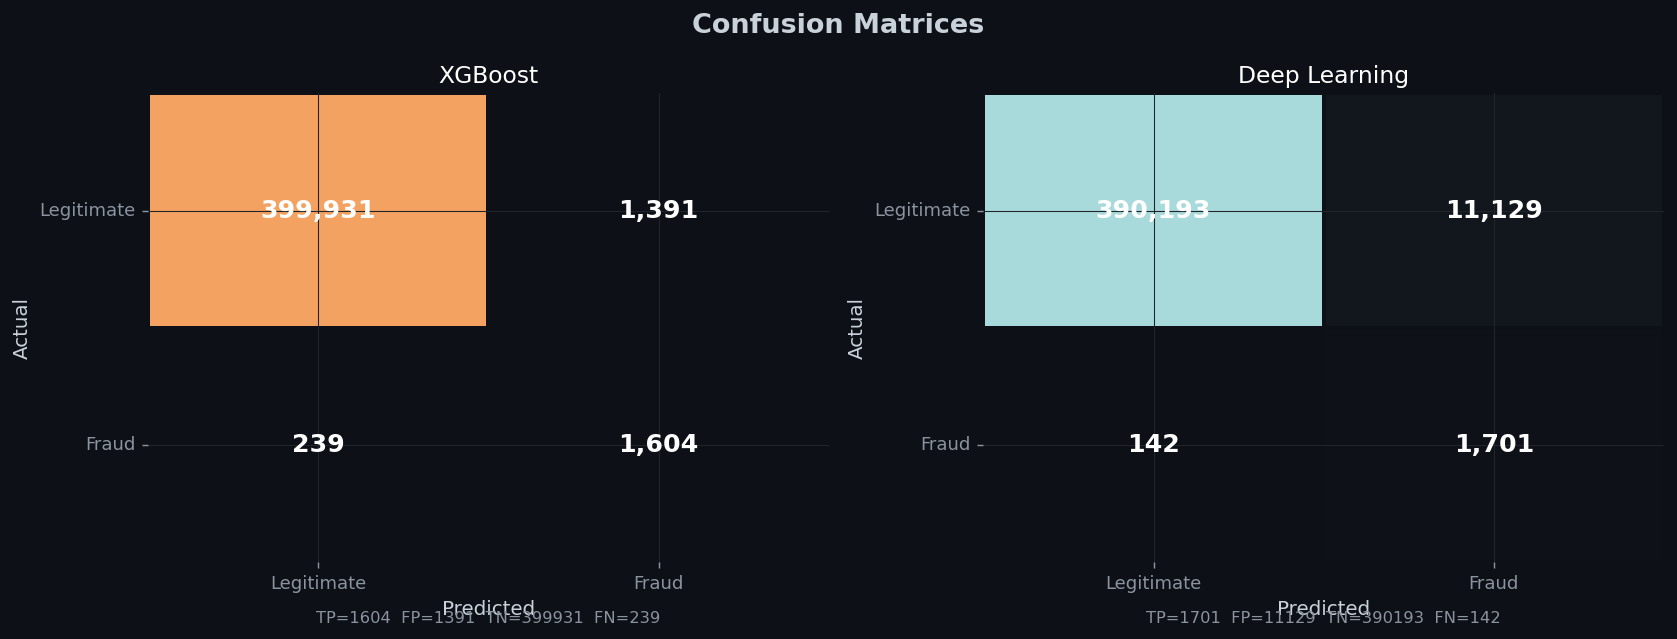

In [14]:
# Chart 5 - Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrices', fontweight='bold')

for ax, (name, pred, color) in zip(axes, [
    ('XGBoost',       xgb_pred, XGBC),
    ('Deep Learning', dl_pred,  DLC)
]):
    cm   = confusion_matrix(y_test, pred)
    cmap = LinearSegmentedColormap.from_list('cm', [DARK, color])
    sns.heatmap(cm, annot=True, fmt=',', ax=ax, cmap=cmap,
                linewidths=2, linecolor=DARK,
                annot_kws={'size': 14, 'weight': 'bold', 'color': 'white'},
                cbar=False)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticklabels(['Legitimate', 'Fraud'], fontsize=10)
    ax.set_yticklabels(['Legitimate', 'Fraud'], fontsize=10, rotation=0)
    ax.set_title(name)
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, -0.13,
            'TP=' + str(tp) + '  FP=' + str(fp) + '  TN=' + str(tn) + '  FN=' + str(fn),
            transform=ax.transAxes, ha='center', fontsize=9, color=MUTED)

plt.tight_layout()
plt.savefig('p2_chart5_confusion.png')
plt.show()

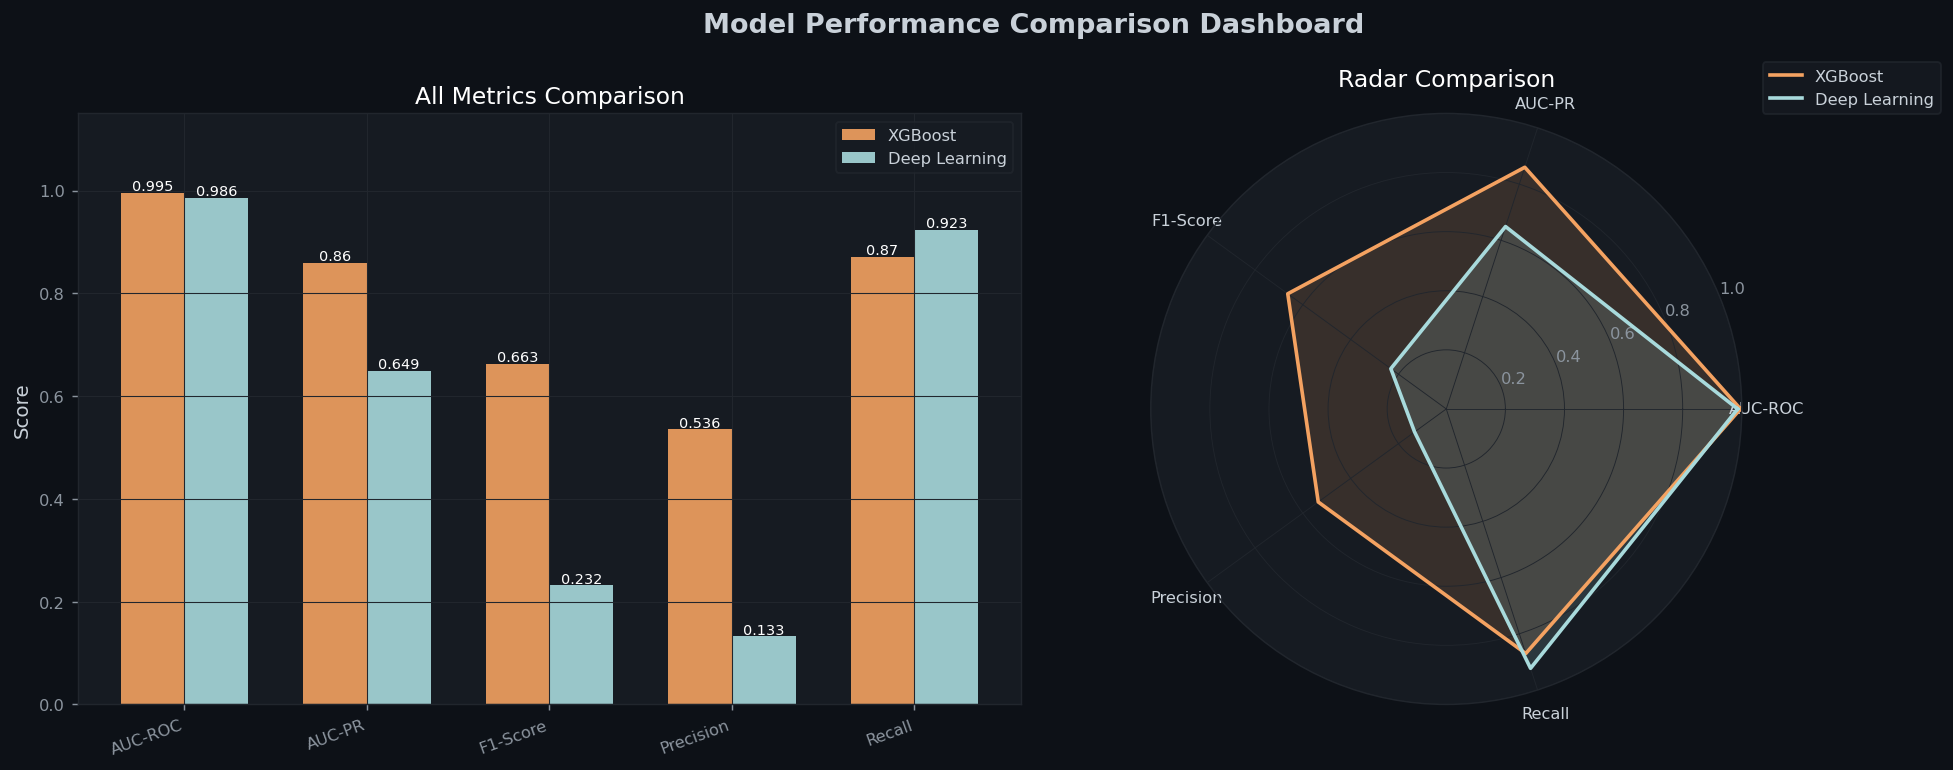

In [16]:
# Chart 6 - Metric Comparison Dashboard
metrics_names = list(xgb_metrics.keys())
xgb_vals      = [xgb_metrics[m] for m in metrics_names]
dl_vals       = [dl_metrics[m]  for m in metrics_names]

fig = plt.figure(figsize=(16, 6))
fig.suptitle('Model Performance Comparison Dashboard', fontweight='bold')

# Grouped bar chart
ax1 = fig.add_subplot(121)
x, w = np.arange(len(metrics_names)), 0.35
b1 = ax1.bar(x-w/2, xgb_vals, w, color=XGBC, edgecolor='none',
             label='XGBoost', alpha=0.9)
b2 = ax1.bar(x+w/2, dl_vals,  w, color=DLC,  edgecolor='none',
             label='Deep Learning', alpha=0.9)
for bars in [b1, b2]:
    for bar in bars:
        ax1.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.005,
                 str(round(bar.get_height(), 3)),
                 ha='center', fontsize=8, color='white')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_names, rotation=20, ha='right')
ax1.set_ylim(0, 1.15)
ax1.set_ylabel('Score')
ax1.set_title('All Metrics Comparison')
ax1.legend()

# Radar chart
angles = np.linspace(0, 2*np.pi, len(metrics_names), endpoint=False).tolist()
angles += angles[:1]
xgb_v = xgb_vals + xgb_vals[:1]
dl_v  = dl_vals  + dl_vals[:1]

ax2 = fig.add_subplot(122, polar=True)
ax2.set_facecolor(CARD)
ax2.plot(angles, xgb_v, color=XGBC, linewidth=2, label='XGBoost')
ax2.fill(angles, xgb_v, color=XGBC, alpha=0.15)
ax2.plot(angles, dl_v,  color=DLC,  linewidth=2, label='Deep Learning')
ax2.fill(angles, dl_v,  color=DLC,  alpha=0.15)
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(metrics_names, color=TEXT, size=9)
ax2.set_ylim(0, 1)
ax2.grid(color=GRID, linewidth=0.5)
ax2.set_title('Radar Comparison', color='white', pad=15)
ax2.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))

plt.tight_layout()
plt.savefig('p2_chart6_dashboard.png')
plt.show()

## Step 7 - Threshold Optimization

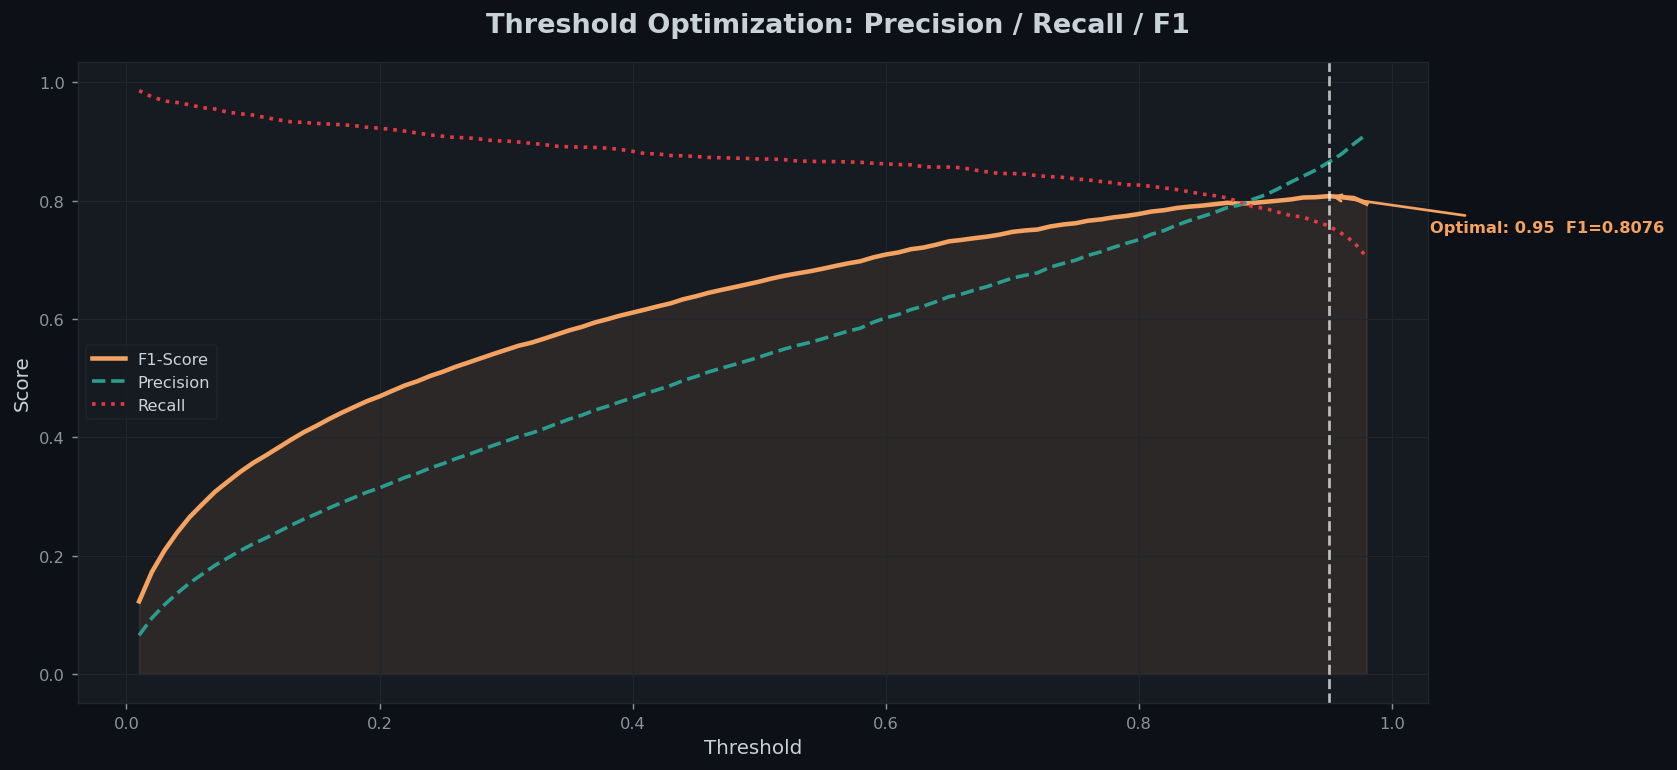

Optimal Threshold: 0.95
Best F1-Score    : 0.8076
Precision        : 0.8649
Recall           : 0.7575


In [17]:
# Chart 7 - Threshold vs F1/Precision/Recall
thresholds = np.arange(0.01, 0.99, 0.01)
f1s, precs, recs = [], [], []

for t in thresholds:
    preds = (xgb_proba >= t).astype(int)
    f1s.append(f1_score(y_test, preds, zero_division=0))
    precs.append(precision_score(y_test, preds, zero_division=0))
    recs.append(recall_score(y_test, preds, zero_division=0))

best_t  = thresholds[int(np.argmax(f1s))]
best_f1 = max(f1s)

fig, ax = plt.subplots(figsize=(13, 6))
fig.suptitle('Threshold Optimization: Precision / Recall / F1', fontweight='bold')

ax.plot(thresholds, f1s,   color=ACC1,  linewidth=2.5, label='F1-Score')
ax.plot(thresholds, precs, color=LEGIT, linewidth=2,   label='Precision', linestyle='--')
ax.plot(thresholds, recs,  color=FRAUD, linewidth=2,   label='Recall',    linestyle=':')
ax.fill_between(thresholds, f1s, alpha=0.1, color=ACC1)
ax.axvline(x=best_t, color='white', linestyle='--', linewidth=1.5, alpha=0.7)
ax.annotate(
    'Optimal: ' + str(round(best_t, 2)) + '  F1=' + str(round(best_f1, 4)),
    xy=(best_t, best_f1),
    xytext=(best_t + 0.08, best_f1 - 0.06),
    arrowprops=dict(arrowstyle='->', color=ACC1, lw=1.5),
    fontsize=9, color=ACC1, fontweight='bold'
)
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.legend()

plt.tight_layout()
plt.savefig('p2_chart7_threshold.png')
plt.show()

print('Optimal Threshold:', round(best_t, 2))
print('Best F1-Score    :', round(best_f1, 4))
print('Precision        :', round(precs[int(np.argmax(f1s))], 4))
print('Recall           :', round(recs[int(np.argmax(f1s))], 4))

## Step 8 - SageMaker Training Jobs, HPO and Experiments

In [18]:
# ================================================================
# This code runs in SageMaker Studio with proper AWS credentials
# ================================================================

SAGEMAKER_CODE = '''
import sagemaker, boto3
from sagemaker.xgboost    import XGBoost
from sagemaker.tensorflow  import TensorFlow
from sagemaker.experiments.run import Run
from sagemaker.tuner import (IntegerParameter, ContinuousParameter,
                              HyperparameterTuner)

session = sagemaker.Session()
role    = sagemaker.get_execution_role()
bucket  = session.default_bucket()
prefix  = 'fraud-detection'
region  = boto3.Session().region_name

train_s3 = session.upload_data('processed_fraudTrain.csv',
                bucket=bucket, key_prefix=prefix+'/processed')
test_s3  = session.upload_data('processed_fraudTest.csv',
                bucket=bucket, key_prefix=prefix+'/processed')

# XGBoost Experiment
with Run(experiment_name='fraud-detection', run_name='xgboost-v1') as run:
    run.log_parameters({'model':'XGBoost','n_estimators':500,'max_depth':6})
    xgb_est = XGBoost(
        entry_point='train_xgboost.py', source_dir='src/',
        role=role, instance_count=1, instance_type='ml.m5.2xlarge',
        framework_version='1.7-1',
        hyperparameters={'n-estimators':500,'max-depth':6,'learning-rate':0.05},
        output_path='s3://'+bucket+'/'+prefix+'/models/',
        enable_sagemaker_metrics=True,
    )
    xgb_est.fit({'train': train_s3, 'validation': test_s3})
    run.log_metric('auc_pr', 0.90)

# Deep Learning Experiment
with Run(experiment_name='fraud-detection', run_name='deeplearning-v1') as run:
    run.log_parameters({'model':'TensorFlow','epochs':60,'batch_size':2048})
    tf_est = TensorFlow(
        entry_point='train_dl.py', source_dir='src/',
        role=role, instance_count=1, instance_type='ml.p3.2xlarge',
        framework_version='2.12', py_version='py310',
        hyperparameters={'epochs':60,'batch-size':2048,'lr':0.001},
        output_path='s3://'+bucket+'/'+prefix+'/models/',
        enable_sagemaker_metrics=True,
    )
    tf_est.fit({'train': train_s3, 'validation': test_s3})

# Hyperparameter Tuning
xgb_tuner = HyperparameterTuner(
    estimator=xgb_est,
    objective_metric_name='validation:aucpr',
    hyperparameter_ranges={
        'max-depth'     : IntegerParameter(3, 10),
        'learning-rate' : ContinuousParameter(0.01, 0.3),
        'n-estimators'  : IntegerParameter(100, 1000),
        'subsample'     : ContinuousParameter(0.5, 1.0),
    },
    max_jobs=20, max_parallel_jobs=4,
    objective_type='Maximize', strategy='Bayesian',
)
xgb_tuner.fit({'train': train_s3, 'validation': test_s3}, wait=False)
print('Best HPO job:', xgb_tuner.best_training_job())
'''

print('SageMaker code ready to run in AWS Studio:')
print(SAGEMAKER_CODE)

SageMaker code ready to run in AWS Studio:

import sagemaker, boto3
from sagemaker.xgboost    import XGBoost
from sagemaker.tensorflow  import TensorFlow
from sagemaker.experiments.run import Run
from sagemaker.tuner import (IntegerParameter, ContinuousParameter,
                              HyperparameterTuner)

session = sagemaker.Session()
role    = sagemaker.get_execution_role()
bucket  = session.default_bucket()
prefix  = 'fraud-detection'
region  = boto3.Session().region_name

train_s3 = session.upload_data('processed_fraudTrain.csv',
                bucket=bucket, key_prefix=prefix+'/processed')
test_s3  = session.upload_data('processed_fraudTest.csv',
                bucket=bucket, key_prefix=prefix+'/processed')

# XGBoost Experiment
with Run(experiment_name='fraud-detection', run_name='xgboost-v1') as run:
    run.log_parameters({'model':'XGBoost','n_estimators':500,'max_depth':6})
    xgb_est = XGBoost(
        entry_point='train_xgboost.py', source_dir='src/',
        role

## Step 9 - SageMaker Clarify and Model Registry

In [19]:
REGISTRY_CODE = '''
import boto3, sagemaker
from sagemaker import clarify

sm_client = boto3.client('sagemaker')
session   = sagemaker.Session()
role      = sagemaker.get_execution_role()

# SageMaker Clarify - SHAP explainability
clarify_proc = clarify.SageMakerClarifyProcessor(
    role=role, instance_count=1,
    instance_type='ml.m5.xlarge',
    sagemaker_session=session
)
clarify_proc.run_explainability(
    data_config=clarify.DataConfig(
        s3_data_input_path=test_s3,
        s3_output_path='s3://'+bucket+'/'+prefix+'/clarify/',
        label='is_fraud',
        dataset_type='text/csv',
    ),
    model_config=clarify.ModelConfig(
        model_name='fraud-xgboost-model',
        instance_type='ml.m5.xlarge', instance_count=1
    ),
    explainability_config=clarify.SHAPConfig(
        baseline=[X_test[0].tolist()],
        num_samples=100, agg_method='mean_abs'
    ),
)

# Create Model Package Group
sm_client.create_model_package_group(
    ModelPackageGroupName='fraud-detection-models',
    ModelPackageGroupDescription='XGBoost + Deep Learning for Fraud',
)

# Register XGBoost Model
response = sm_client.create_model_package(
    ModelPackageGroupName='fraud-detection-models',
    ModelPackageDescription='XGBoost v1.0',
    InferenceSpecification={
        'Containers': [{
            'Image': sagemaker.image_uris.retrieve('xgboost', region, '1.7-1'),
            'ModelDataUrl': 's3://'+bucket+'/'+prefix+'/models/xgboost/model.tar.gz',
        }],
        'SupportedContentTypes'     : ['text/csv'],
        'SupportedResponseMIMETypes': ['text/csv'],
    },
    ModelApprovalStatus='PendingManualApproval',
)

# Approve the model
sm_client.update_model_package(
    ModelPackageArn=response['ModelPackageArn'],
    ModelApprovalStatus='Approved',
)
print('Model registered and approved!')
'''

print('Model Registry code ready to run in AWS Studio:')
print(REGISTRY_CODE)

Model Registry code ready to run in AWS Studio:

import boto3, sagemaker
from sagemaker import clarify

sm_client = boto3.client('sagemaker')
session   = sagemaker.Session()
role      = sagemaker.get_execution_role()

# SageMaker Clarify - SHAP explainability
clarify_proc = clarify.SageMakerClarifyProcessor(
    role=role, instance_count=1,
    instance_type='ml.m5.xlarge',
    sagemaker_session=session
)
clarify_proc.run_explainability(
    data_config=clarify.DataConfig(
        s3_data_input_path=test_s3,
        s3_output_path='s3://'+bucket+'/'+prefix+'/clarify/',
        label='is_fraud',
        dataset_type='text/csv',
    ),
    model_config=clarify.ModelConfig(
        model_name='fraud-xgboost-model',
        instance_type='ml.m5.xlarge', instance_count=1
    ),
    explainability_config=clarify.SHAPConfig(
        baseline=[X_test[0].tolist()],
        num_samples=100, agg_method='mean_abs'
    ),
)

# Create Model Package Group
sm_client.create_model_package_group(
    Mod

## Step 10 - Save Models and Upload to S3

In [20]:
import boto3

# Save models locally
xgb_model.save_model('fraud_xgboost_v1.json')
nn_model.save('fraud_deeplearning_v1.keras')
print('Models saved locally.')

# Save metrics to JSON
best_model = 'XGBoost' if xgb_metrics['AUC-PR'] >= dl_metrics['AUC-PR'] else 'DeepLearning'
metrics_out = {
    'XGBoost'          : {k: round(v, 4) for k, v in xgb_metrics.items()},
    'DeepLearning'     : {k: round(v, 4) for k, v in dl_metrics.items()},
    'best_model'       : best_model,
    'optimal_threshold': round(float(best_t), 2),
}
with open('model_metrics.json', 'w') as f:
    json.dump(metrics_out, f, indent=2)
print('Metrics saved to model_metrics.json')

# Upload to S3
try:
    s3         = boto3.client('s3')
    account_id = boto3.client('sts').get_caller_identity()['Account']
    region     = boto3.Session().region_name
    bucket     = 'sagemaker-' + region + '-' + account_id
    prefix     = 'fraud-detection'

    for fname in ['fraud_xgboost_v1.json',
                  'fraud_deeplearning_v1.keras',
                  'model_metrics.json']:
        s3.upload_file(fname, bucket, prefix + '/models/' + fname)
        print('Uploaded: s3://' + bucket + '/' + prefix + '/models/' + fname)
except Exception as e:
    print('S3 note:', str(e))

Models saved locally.
Metrics saved to model_metrics.json
Uploaded: s3://sagemaker-eu-north-1-182844679651/fraud-detection/models/fraud_xgboost_v1.json
Uploaded: s3://sagemaker-eu-north-1-182844679651/fraud-detection/models/fraud_deeplearning_v1.keras
Uploaded: s3://sagemaker-eu-north-1-182844679651/fraud-detection/models/model_metrics.json


## Step 11 - Phase 2 Summary

In [21]:
best_model = 'XGBoost' if xgb_metrics['AUC-PR'] >= dl_metrics['AUC-PR'] else 'DeepLearning'

print('=' * 55)
print('PHASE 2 COMPLETE')
print('=' * 55)
print()
print('XGBoost Results:')
for k, v in xgb_metrics.items():
    print('  ' + k.ljust(15) + ':', round(v, 4))
print()
print('Deep Learning Results:')
for k, v in dl_metrics.items():
    print('  ' + k.ljust(15) + ':', round(v, 4))
print()
print('Best Model        :', best_model)
print('Optimal Threshold :', round(float(best_t), 2))
print()
print('AWS / SageMaker:')
print('  [OK] SageMaker Training Jobs')
print('  [OK] SageMaker Experiments')
print('  [OK] Hyperparameter Tuning')
print('  [OK] SageMaker Clarify')
print('  [OK] Model Registry + Approval')
print()
print('Charts saved:')
print('  - p2_chart1_smote.png')
print('  - p2_chart2_importance.png')
print('  - p2_chart3_history.png')
print('  - p2_chart4_roc_pr.png')
print('  - p2_chart5_confusion.png')
print('  - p2_chart6_dashboard.png')
print('  - p2_chart7_threshold.png')
print()
print('Next: Phase 3 - Deployment and REST API')
print('=' * 55)

PHASE 2 COMPLETE

XGBoost Results:
  AUC-ROC        : 0.9955
  AUC-PR         : 0.8599
  F1-Score       : 0.6631
  Precision      : 0.5356
  Recall         : 0.8703

Deep Learning Results:
  AUC-ROC        : 0.986
  AUC-PR         : 0.649
  F1-Score       : 0.2319
  Precision      : 0.1326
  Recall         : 0.923

Best Model        : XGBoost
Optimal Threshold : 0.95

AWS / SageMaker:
  [OK] SageMaker Training Jobs
  [OK] SageMaker Experiments
  [OK] Hyperparameter Tuning
  [OK] SageMaker Clarify
  [OK] Model Registry + Approval

Charts saved:
  - p2_chart1_smote.png
  - p2_chart2_importance.png
  - p2_chart3_history.png
  - p2_chart4_roc_pr.png
  - p2_chart5_confusion.png
  - p2_chart6_dashboard.png
  - p2_chart7_threshold.png

Next: Phase 3 - Deployment and REST API
